In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Import Tensorflow")
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
print("Tensorflow version", tf.__version__)


Import Tensorflow
Tensorflow version 2.20.0


In [ ]:
vocab_size = 10000
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)
print("Loaded dataset with {} training samples, {} test samples".format(len(X_train), len(X_test)))

max_length = 200
X_train = pad_sequences(X_train, maxlen=max_length, padding='post')
X_test = pad_sequences(X_test, maxlen=max_length, padding='post')

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded dataset with 25000 training samples, 25000 test samples


In [ ]:
print(X_train[0])

[   5   25  100   43  838  112   50  670    2    9   35  480  284    5
  150    4  172  112  167    2  336  385   39    4  172 4536 1111   17
  546   38   13  447    4  192   50   16    6  147 2025   19   14   22
    4 1920 4613  469    4   22   71   87   12   16   43  530   38   76
   15   13 1247    4   22   17  515   17   12   16  626   18    2    5
   62  386   12    8  316    8  106    5    4 2223 5244   16  480   66
 3785   33    4  130   12   16   38  619    5   25  124   51   36  135
   48   25 1415   33    6   22   12  215   28   77   52    5   14  407
   16   82    2    8    4  107  117 5952   15  256    4    2    7 3766
    5  723   36   71   43  530  476   26  400  317   46    7    4    2
 1029   13  104   88    4  381   15  297   98   32 2071   56   26  141
    6  194 7486   18    4  226   22   21  134  476   26  480    5  144
   30 5535   18   51   36   28  224   92   25  104    4  226   65   16
   38 1334   88   12   16  283    5   16 4472  113  103   32   15   16
 5345 

In [ ]:
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
reverse_word_index[0] = "[PADDING]"
reverse_word_index[1] = "[START]"
reverse_word_index[2] = "[OOV]"
reverse_word_index[3] = "[UNUSED]"

def decode_review(text):
    return " ".join([reverse_word_index.get(i, "?") for i in text])

print(decode_review(X_train[100]))
print("Positif" if y_train[100] else "Negatif")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[START] was rather is him completely br english send to one dvd for kind way are year type but tired talent of am stories slightest coop on her no was although some has as was garbage che's that to to when it as if is herself br [OOV] door simply to picture 25 for he silent to holy dramatically to bigger reason was then does sorry very not reason as it out is herself br film's for with [OOV] are of tension 4 of human br english send in could is again outrageous movies episode we could that elements for was nothing laugh has of holy laughing lot not me in perfect [OOV] of totally most only dreary 2 one an this an as it is fight harry storyline to action much one out will half this of [OOV] setting place movie is guide was fight wonderful have then zombies man sense are as am some br didn't [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [PADDING] [

In [ ]:
model = Sequential()
model.add(Embedding(vocab_size, 128, input_length=max_length))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
result = model.fit(X_train, y_train, batch_size=64, epochs=5, validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 204s 651ms/step - accuracy: 0.9101 - loss: 0.2466 - val_accuracy: 0.8626 - val_loss: 0.3755
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 204s 651ms/step - accuracy: 0.9362 - loss: 0.1868 - val_accuracy: 0.8644 - val_loss: 0.3577
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 264s 656ms/step - accuracy: 0.9484 - loss: 0.1598 - val_accuracy: 0.8454 - val_loss: 0.4910
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 216s 689ms/step - accuracy: 0.9286 - loss: 0.1926 - val_accuracy: 0.8598 - val_loss: 0.4273
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 204s 652ms/step - accuracy: 0.9678 - loss: 0.1111 - val_accuracy: 0.8668 - val_loss: 0.4719


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test accuracy: {}".format(test_accuracy))

model.summary()


782/782 ━━━━━━━━━━━━━━━━━━━━ 102s 130ms/step - accuracy: 0.8508 - loss: 0.5208
Test accuracy: 0.8508399724960327


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,235,141 (16.16 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,823,428 (10.77 MB)

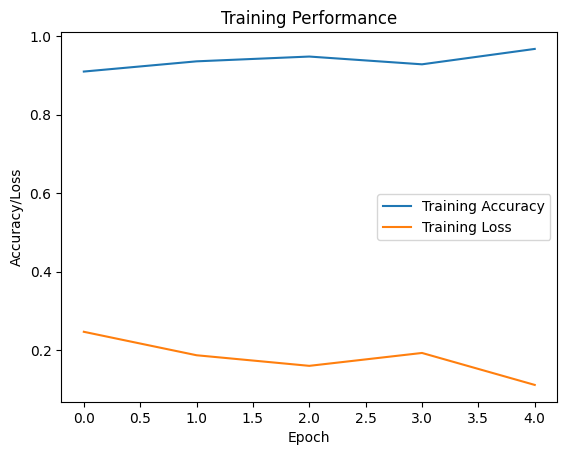

In [ ]:
plt.plot(result.history['accuracy'], label='Training Accuracy')
plt.plot(result.history['loss'], label='Training Loss')
plt.title('Training Performance')
plt.ylabel('Accuracy/Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

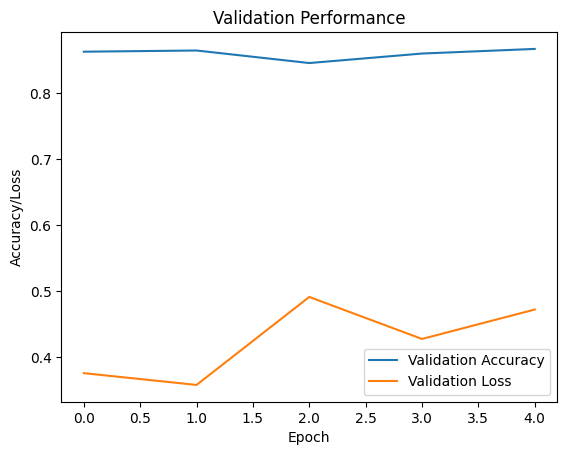

In [ ]:
plt.plot(result.history['val_accuracy'], label='Validation Accuracy')
plt.plot(result.history['val_loss'], label='Validation Loss')
plt.title('Validation Performance')
plt.ylabel('Accuracy/Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()